This notebook provides a high-level demonstration on Kausal's functionality. In particular, you will learn how to:
- Estimate causal effect from pairwise timeseries
- Obtain uncertainty quantification through bootstrap sampling
- Perform conditional forecasting
- Using neural network to augment features

Throughout, we will use the coupled Rossler example as described in the paper.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import torch
import torchdiffeq
from torch.nn import functional as F

import matplotlib.pyplot as plt
from matplotlib import cm, colors as mcolors
from mpl_toolkits.mplot3d import Axes3D
from tqdm import tqdm

from kausal.koopman import Kausal
from kausal.generator import coupled_rossler
from kausal.observables import RandomFourierFeatures, MLPFeatures

import warnings
warnings.filterwarnings('ignore')


# 1. Generate dynamics 
First, we are going to generate the dynamics of coupled Rossler as described in the paper.

In [3]:
# Let's first generate the dynamics
t0, t1 = 0.0, 40.0
dt = 0.01
steps = int((t1 - t0) / dt)
n_train = int(0.8 * steps)

initial_state = torch.tensor([1.0, -2.0, 0.0, 0.0, 0.0, 0.0])

phi1, phi2 = 1.0, 1.0  # Frequencies
a, b, d = 0.2, 0.2, 5.7  # Rössler parameters
c1, c2 = 0.5, 0 # Coupling term
params = (phi1, phi2, a, b, d, c1, c2)

# Define the dynamics solver
def solve_dynamics(t0, t1, dt, initial_state, params):
    """Solve dynamics"""
    t = torch.linspace(t0, t1, int((t1 - t0) / dt))
    dynamics = lambda t, state: coupled_rossler(t, state, params)
    
    solution = solver(
        dynamics,
        initial_state,
        t,
        method='dopri5',
        options={'max_num_steps': 100000}
    )
    return t, solution

# Solve the system
solver = torchdiffeq.odeint
t, solution = solve_dynamics(t0, t1, dt, initial_state, params)

# Extract results (divided into omega_1, omega_2)
omega_1 = solution.T[:3] # True effect variables
omega_2 = solution.T[3:] # True cause variables


print(omega_1.shape, omega_2.shape) # (num_features, n_steps)


torch.Size([3, 4000]) torch.Size([3, 4000])


# 2. Causal Estimation

This section describes how we can get causal magnitudes. 

Expected behaviors:
1. __True causal relationship__: Increasing causal 'error' between the marginal and joint models.
2. __False causal relationship__: Low, stationary causal 'error' between the marginal and joint models.

Here, we evaluate the temporal dependency analysis.

In [4]:
# Initialize Kausal object, where we can pass in the cause-effect variables to be analyzed

## Test C --> E (true causal direction)
causal_koopman = Kausal(
    cause = omega_2,
    effect = omega_1,
)

## Test E --> C (false causal direction)
noncausal_koopman = Kausal(
    cause = omega_1,
    effect = omega_2
)


In [5]:
# If you want to obtain causal effect from one single time_shift (e.g., x_t --> y_{t + delta})
causal_effect, _ = causal_koopman.evaluate(
    time_shift=1, 
    bootstrap_ratio=0.9, ## Subtrajectory length ratio used for bootstrapping
    bootstrap_nums=100   ## Number of bootstrapping resampling
)

non_causal_effect, _ = noncausal_koopman.evaluate(
    time_shift=1, 
    bootstrap_ratio=0.9, ## Subtrajectory length ratio used for bootstrapping
    bootstrap_nums=100   ## Number of bootstrapping resampling
)

print(causal_effect.shape, non_causal_effect.shape) ## Output has the shape of (bootstrap_nums, )


torch.Size([100]) torch.Size([100])


In [6]:
# In other cases, you want to get causal effect as timeseries
# You can call the evaluate_multistep() function instead

time_shifts = torch.arange(1, 2000, 50)

## 1. Causal effect
causal_effect, _ = causal_koopman.evaluate_multistep(
    time_shifts=time_shifts, 
    bootstrap_ratio=0.9, ## Subtrajectory length ratio used for bootstrapping
    bootstrap_nums=100   ## Number of bootstrapping resampling
)

## 2. Non-causal effect
non_causal_effect, _ = noncausal_koopman.evaluate_multistep(
    time_shifts=time_shifts, 
    bootstrap_ratio=0.9, ## Subtrajectory length ratio used for bootstrapping
    bootstrap_nums=100   ## Number of bootstrapping resampling
)

print(causal_effect.shape, non_causal_effect.shape) ## Output has the shape of (time_shifts, bootstrap_nums)


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:22<00:00,  1.79it/s]

torch.Size([40, 100]) torch.Size([40, 100])


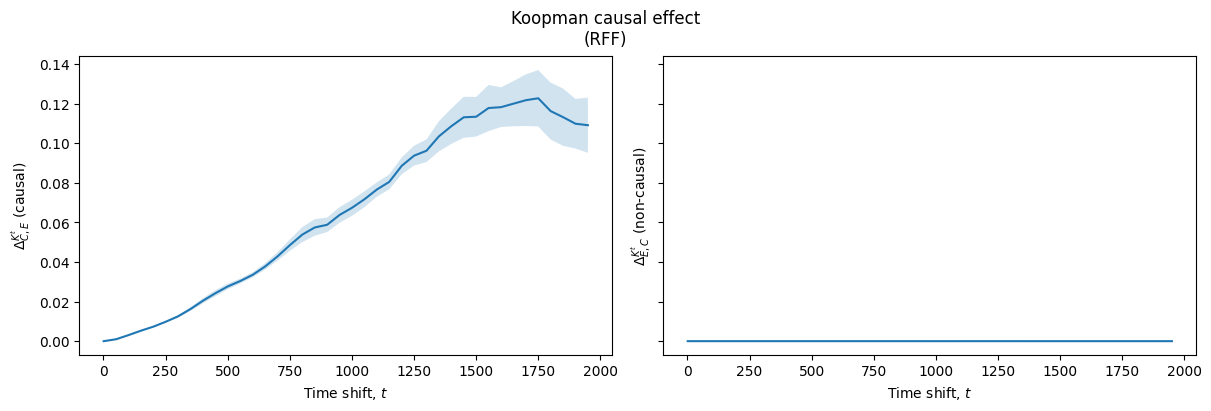

In [7]:
# Plot causal effects
# NOTE: increasing causal error in the true causal direction as time dependency increases.
# NOTE: also significant difference between C --> E and E --> C, indicating strong causal signal between C --> E

fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True, constrained_layout=True)
ax[0].plot(time_shifts, causal_effect.mean(axis=1))
ax[0].fill_between(
    time_shifts, 
    causal_effect.mean(axis=1) - causal_effect.std(axis=1), 
    causal_effect.mean(axis=1) + causal_effect.std(axis=1), 
    alpha=0.2
)
ax[0].set_xlabel(r'Time shift, $t$')
ax[0].set_ylabel(r'$\Delta^{K^t}_{C,E}$ (causal)')

ax[1].plot(time_shifts, non_causal_effect.mean(axis=1))
ax[1].fill_between(
    time_shifts, 
    non_causal_effect.mean(axis=1) - non_causal_effect.std(axis=1), 
    non_causal_effect.mean(axis=1) + non_causal_effect.std(axis=1), 
    alpha=0.2
)
ax[1].set_xlabel(r'Time shift, $t$')
ax[1].set_ylabel(r'$\Delta^{K^t}_{E,C}$ (non-causal)')

fig.suptitle(f'Koopman causal effect\n(RFF)')
plt.show();


# 3. Conditional forecast
Once you have learned the Koopman operators for e.g., $\Delta T=1$, you can in principle make forecasts given initial condition. See our paper's section on **Conditional Forecasting** for more details.

Expected behaviors:
1. __True causal relationship__: imperfect match in the marginal model, but better in the joint model since the former lacks the key causal variables.
2. __False causal relationship__: perfect match in the marginal and joint models, since the 'false causal' variables are not useful to make skillful forecast.

In [8]:
# Conditional inference (causal)
# Expected behavior: imperfect match in the marginal model, but better in the joint model.
cause = omega_2
effect = omega_1

omega_marginal, omega_joint = causal_koopman.forecast(
    n_train = n_train,
    time_shift = 1
)


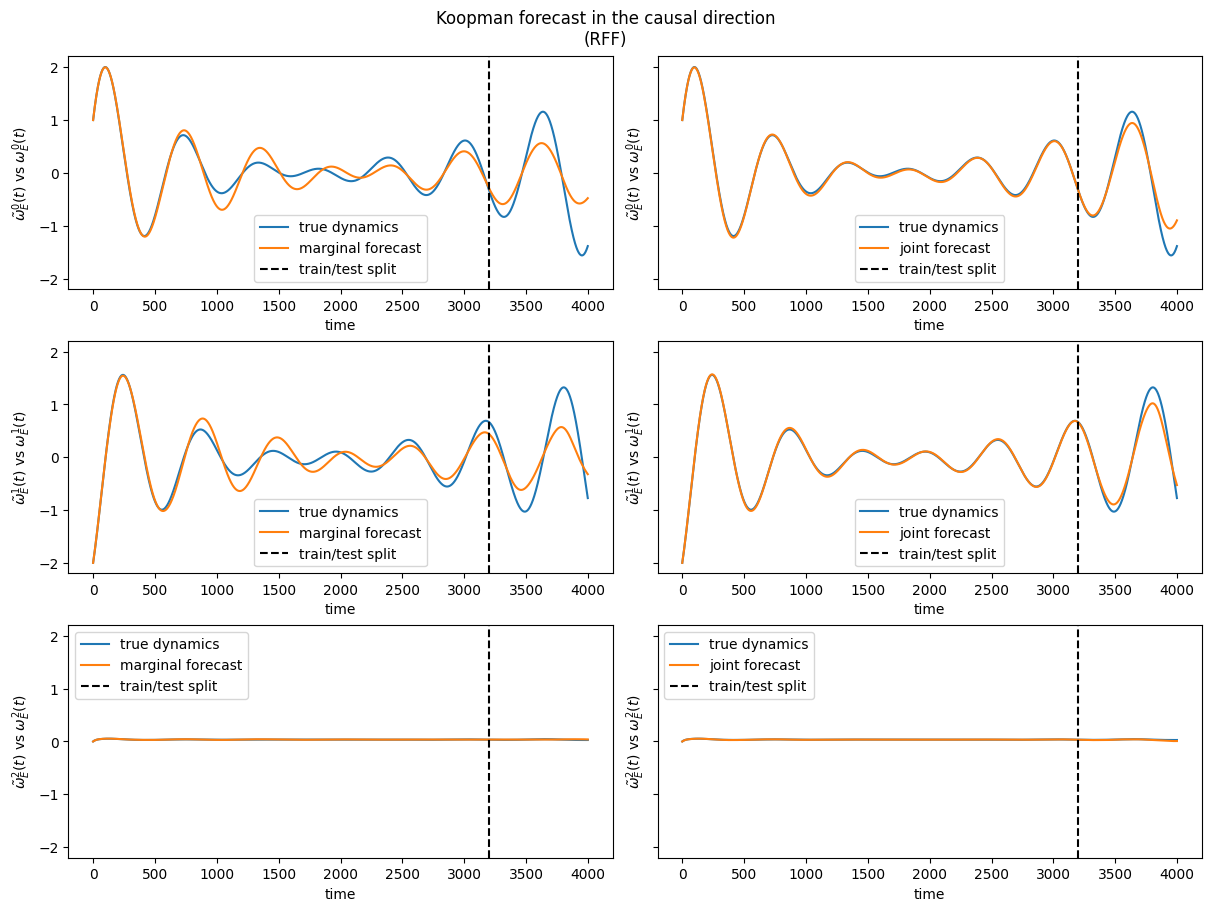

In [9]:
# Plot (conditional inference: causal)
fig, ax = plt.subplots(len(effect), 2, figsize=(12, 3 * len(effect)), sharey=True, constrained_layout=True)

for param_id in range(effect.shape[0]):
    # Left subplot: marginal forecast
    ax[param_id, 0].plot(effect[param_id], label='true dynamics')
    ax[param_id, 0].plot(omega_marginal[param_id], label='marginal forecast')
    ax[param_id, 0].axvline(n_train, color='black', linestyle='--', label='train/test split') 
    ax[param_id, 0].set_xlabel('time')
    ax[param_id, 0].set_ylabel(rf'$\tilde{{\omega}}_E^{{{param_id}}}(t)$ vs $\omega_E^{{{param_id}}}(t)$')
    ax[param_id, 0].legend()

    # Right subplot: joint forecast
    ax[param_id, 1].plot(effect[param_id], label='true dynamics')
    ax[param_id, 1].plot(omega_joint[param_id], label='joint forecast')
    ax[param_id, 1].axvline(n_train, color='black', linestyle='--', label='train/test split') 
    ax[param_id, 1].set_xlabel('time')
    ax[param_id, 1].set_ylabel(rf'$\tilde{{\omega}}_E^{{{param_id}}}(t)$ vs $\omega_E^{{{param_id}}}(t)$')
    ax[param_id, 1].legend()

# Add title above all subplots
fig.suptitle('Koopman forecast in the causal direction\n(RFF)')
plt.show();


In [10]:
# Conditional inference (non-causal)
# Expected behavior: better match in both the marginal and joint models.
cause = omega_1
effect = omega_2

omega_marginal, omega_joint = noncausal_koopman.forecast(
    n_train = n_train,
    time_shift = 1
)


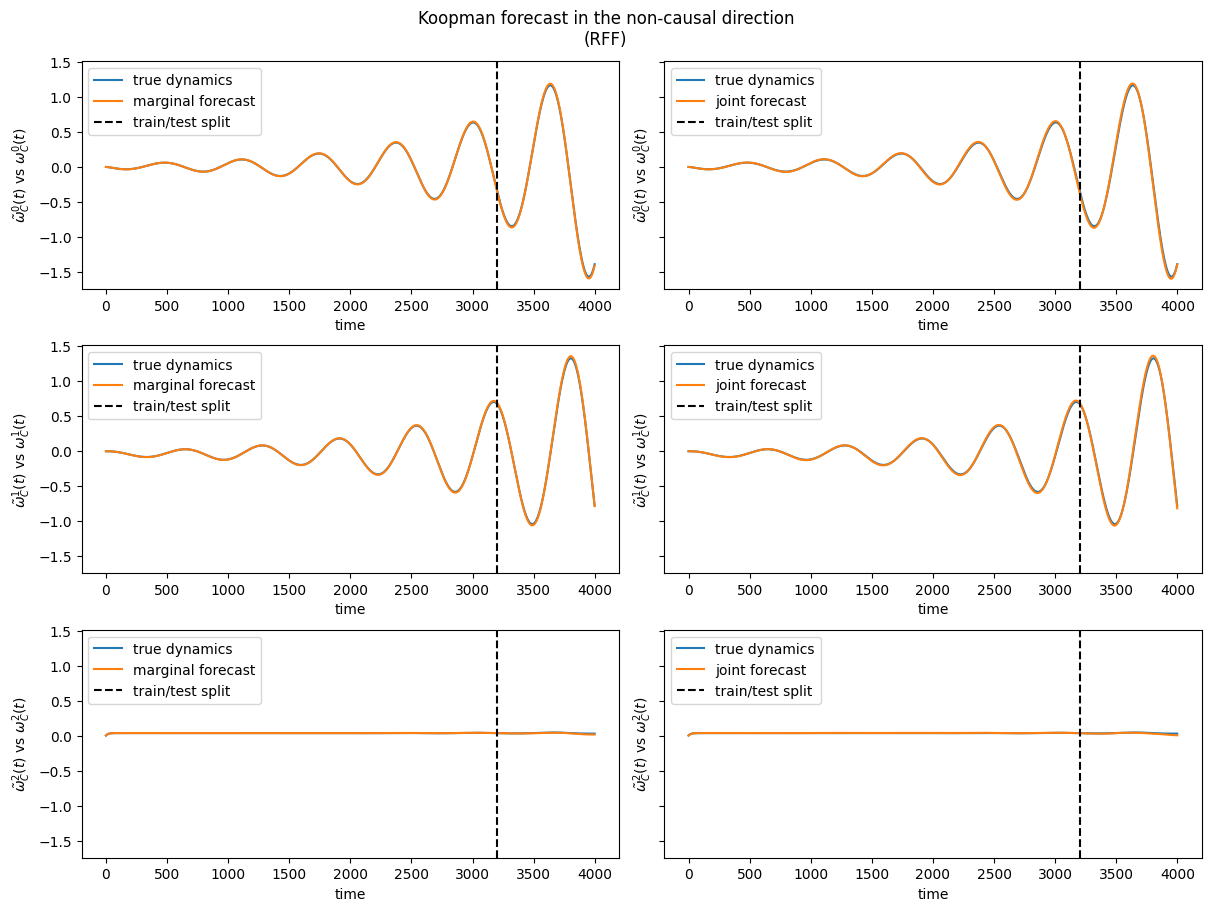

In [11]:
# Plot (conditional inference: non-causal)
fig, ax = plt.subplots(len(effect), 2, figsize=(12, 3 * len(effect)), sharey=True, constrained_layout=True)

for param_id in range(effect.shape[0]):
    # Left subplot: marginal forecast
    ax[param_id, 0].plot(effect[param_id], label='true dynamics')
    ax[param_id, 0].plot(omega_marginal[param_id], label='marginal forecast')
    ax[param_id, 0].axvline(n_train, color='black', linestyle='--', label='train/test split') 
    ax[param_id, 0].set_xlabel('time')
    ax[param_id, 0].set_ylabel(rf'$\tilde{{\omega}}_C^{{{param_id}}}(t)$ vs $\omega_C^{{{param_id}}}(t)$')
    ax[param_id, 0].legend()

    # Right subplot: joint forecast
    ax[param_id, 1].plot(effect[param_id], label='true dynamics')
    ax[param_id, 1].plot(omega_joint[param_id], label='joint forecast')
    ax[param_id, 1].axvline(n_train, color='black', linestyle='--', label='train/test split') 
    ax[param_id, 1].set_xlabel('time')
    ax[param_id, 1].set_ylabel(rf'$\tilde{{\omega}}_C^{{{param_id}}}(t)$ vs $\omega_C^{{{param_id}}}(t)$')
    ax[param_id, 1].legend()

# Add title above all subplots
fig.suptitle('Koopman forecast in the non-causal direction\n(RFF)')
plt.show();


# 4. With Deep Learning
Now, we use neural network (encoder-decoder __MLP__) to approximate the lifting operators, i.e., y(t) = f[x(t)], where x(t) is the high-dimensional non-linear states, and y(t) is the observables. We perform similar causal analysis as above!

In [12]:
# Initialize Kausal object, where we now specify DL-based observable functions.

# Specify hyperparameters
hidden_channels = [16, 32]

## Test C --> E (true causal direction)
causal_koopman = Kausal(
    marginal_observable = MLPFeatures(in_channels=3, hidden_channels=hidden_channels, out_channels=3),
    joint_observable = MLPFeatures(in_channels=6, hidden_channels=hidden_channels, out_channels=3),
    cause = omega_2,
    effect = omega_1,
)

## Test E --> C (false causal direction)
noncausal_koopman = Kausal(
    marginal_observable = MLPFeatures(in_channels=3, hidden_channels=hidden_channels, out_channels=3),
    joint_observable = MLPFeatures(in_channels=6, hidden_channels=hidden_channels, out_channels=3),
    cause = omega_1,
    effect = omega_2
)


In [13]:
# We first have to fit/train the observable functions
lr = 1e-2
epochs = 500

# 1. Causal direction
marginal_loss_ce, joint_loss_ce = causal_koopman.fit(
    n_train = n_train, 
    epochs = epochs, 
    lr = lr, 
    batch_size = n_train
)

# 2. Non-causal direction
marginal_loss_ec, joint_loss_ec = noncausal_koopman.fit(
    n_train = n_train, 
    epochs = epochs, 
    lr = lr, 
    batch_size = n_train
)


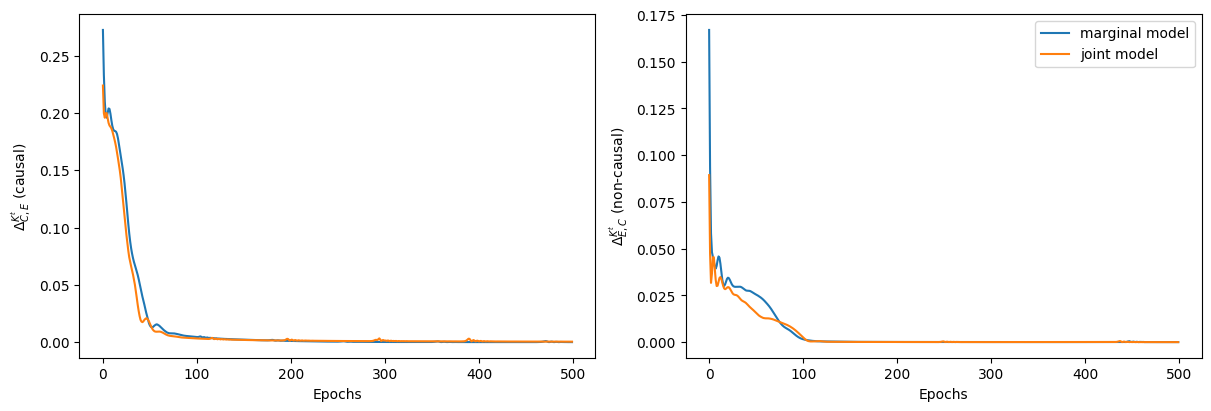

In [14]:
# Plot training losses
fig, ax = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
ax[0].plot(marginal_loss_ce, label='marginal model')
ax[0].plot(joint_loss_ce, label='joint model')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel(r'$\Delta^{K^t}_{C,E}$ (causal)')

ax[1].plot(marginal_loss_ec, label='marginal model')
ax[1].plot(joint_loss_ec, label='joint model')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel(r'$\Delta^{K^t}_{E,C}$ (non-causal)')

plt.legend()
plt.show();


### 4a. Causal dependence with increasing shifts

In [15]:
# Causal effect is estimated through the (marginal - joint) loss
time_shifts = torch.arange(1, 2000, 50)

## 1. Causal effect
causal_effect, _ = causal_koopman.evaluate_multistep(
    time_shifts=time_shifts, 
    bootstrap_ratio=0.9, 
    bootstrap_nums=100
)

## 2. Non-causal effect
non_causal_effect, _ = noncausal_koopman.evaluate_multistep(
    time_shifts=time_shifts, 
    bootstrap_ratio=0.9, 
    bootstrap_nums=100
)


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:08<00:00,  4.89it/s]


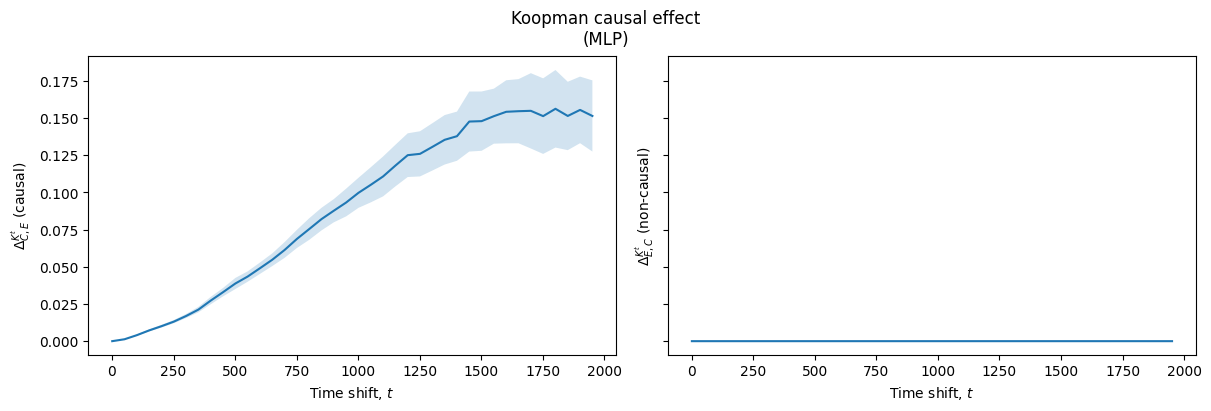

In [16]:
# Plot causal shift
# NOTE: increasing causal error in the true causal direction as time dependency increases.
# NOTE: also significant difference between C --> E and E --> C, indicating strong causal signal between C --> E

fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True, constrained_layout=True)
ax[0].plot(time_shifts, causal_effect.mean(axis=1))
ax[0].fill_between(
    time_shifts, 
    causal_effect.mean(axis=1) - causal_effect.std(axis=1), 
    causal_effect.mean(axis=1) + causal_effect.std(axis=1), 
    alpha=0.2
)
ax[0].set_xlabel(r'Time shift, $t$')
ax[0].set_ylabel(r'$\Delta^{K^t}_{C,E}$ (causal)')

ax[1].plot(time_shifts, non_causal_effect.mean(axis=1))
ax[1].fill_between(
    time_shifts, 
    non_causal_effect.mean(axis=1) - non_causal_effect.std(axis=1), 
    non_causal_effect.mean(axis=1) + non_causal_effect.std(axis=1), 
    alpha=0.2
)
ax[1].set_xlabel(r'Time shift, $t$')
ax[1].set_ylabel(r'$\Delta^{K^t}_{E,C}$ (non-causal)')

fig.suptitle(f'Koopman causal effect\n(MLP)')
plt.show();


### 4b. Conditioning forecasting

In [17]:
# Conditional inference (causal)
# Expected behavior: imperfect match in the marginal model, but better in joint.
cause = omega_2
effect = omega_1

with torch.no_grad():
    omega_marginal, omega_joint = causal_koopman.forecast(
        n_train = n_train,
        time_shift = 1
    )


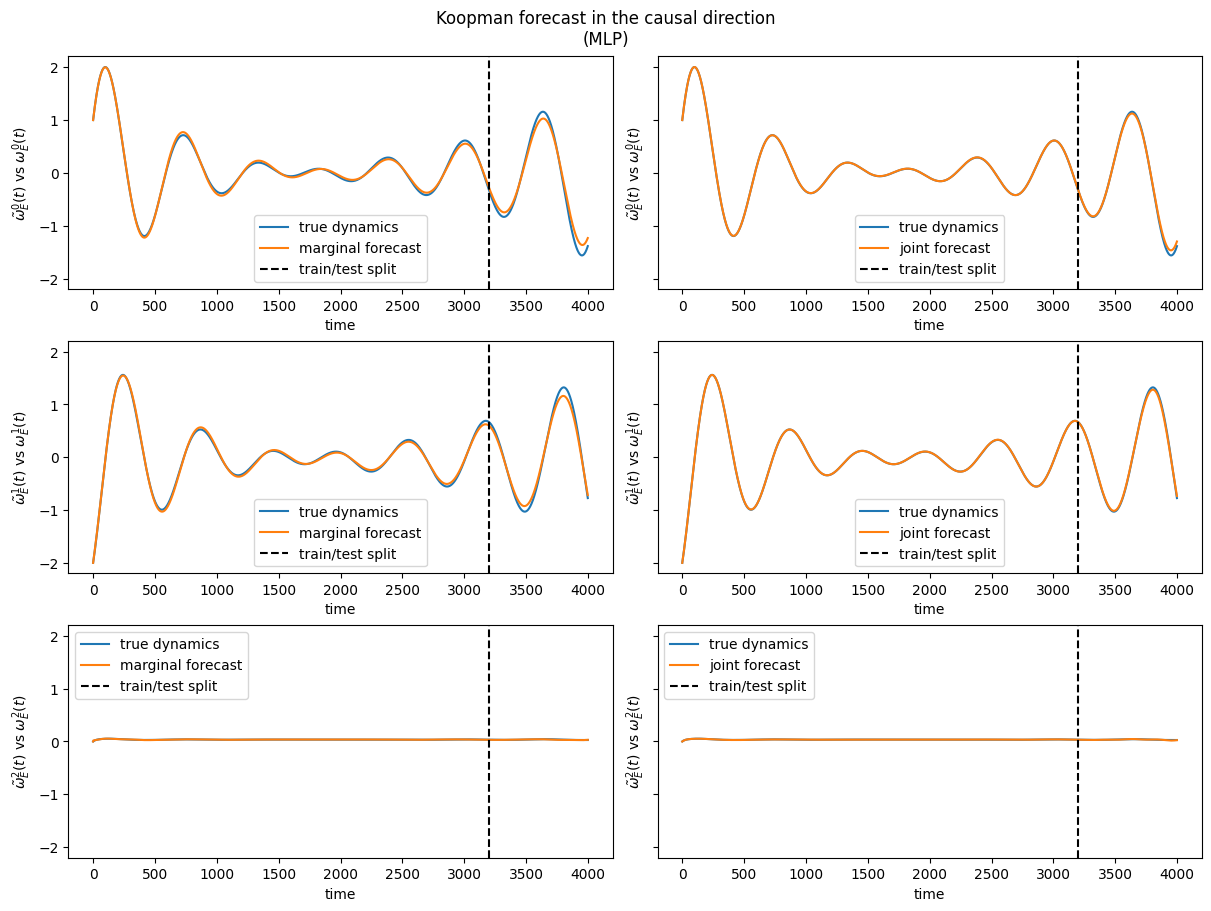

In [18]:
# Plot (conditional inference: causal)
fig, ax = plt.subplots(len(effect), 2, figsize=(12, 3 * len(effect)), sharey=True, constrained_layout=True)

for param_id in range(effect.shape[0]):
    # Left subplot: marginal forecast
    ax[param_id, 0].plot(effect[param_id], label='true dynamics')
    ax[param_id, 0].plot(omega_marginal[param_id], label='marginal forecast')
    ax[param_id, 0].axvline(n_train, color='black', linestyle='--', label='train/test split') 
    ax[param_id, 0].set_xlabel('time')
    ax[param_id, 0].set_ylabel(rf'$\tilde{{\omega}}_E^{{{param_id}}}(t)$ vs $\omega_E^{{{param_id}}}(t)$')
    ax[param_id, 0].legend()

    # Right subplot: joint forecast
    ax[param_id, 1].plot(effect[param_id], label='true dynamics')
    ax[param_id, 1].plot(omega_joint[param_id], label='joint forecast')
    ax[param_id, 1].axvline(n_train, color='black', linestyle='--', label='train/test split') 
    ax[param_id, 1].set_xlabel('time')
    ax[param_id, 1].set_ylabel(rf'$\tilde{{\omega}}_E^{{{param_id}}}(t)$ vs $\omega_E^{{{param_id}}}(t)$')
    ax[param_id, 1].legend()

# Add title above all subplots
fig.suptitle('Koopman forecast in the causal direction\n(MLP)')
plt.show();


In [19]:
# Conditional inference (non-causal)
# Expected behavior: better match in both marginal and joint models.
cause = omega_1
effect = omega_2

with torch.no_grad():
    omega_marginal, omega_joint = noncausal_koopman.forecast(
        n_train = n_train,
        time_shift = 1
    )


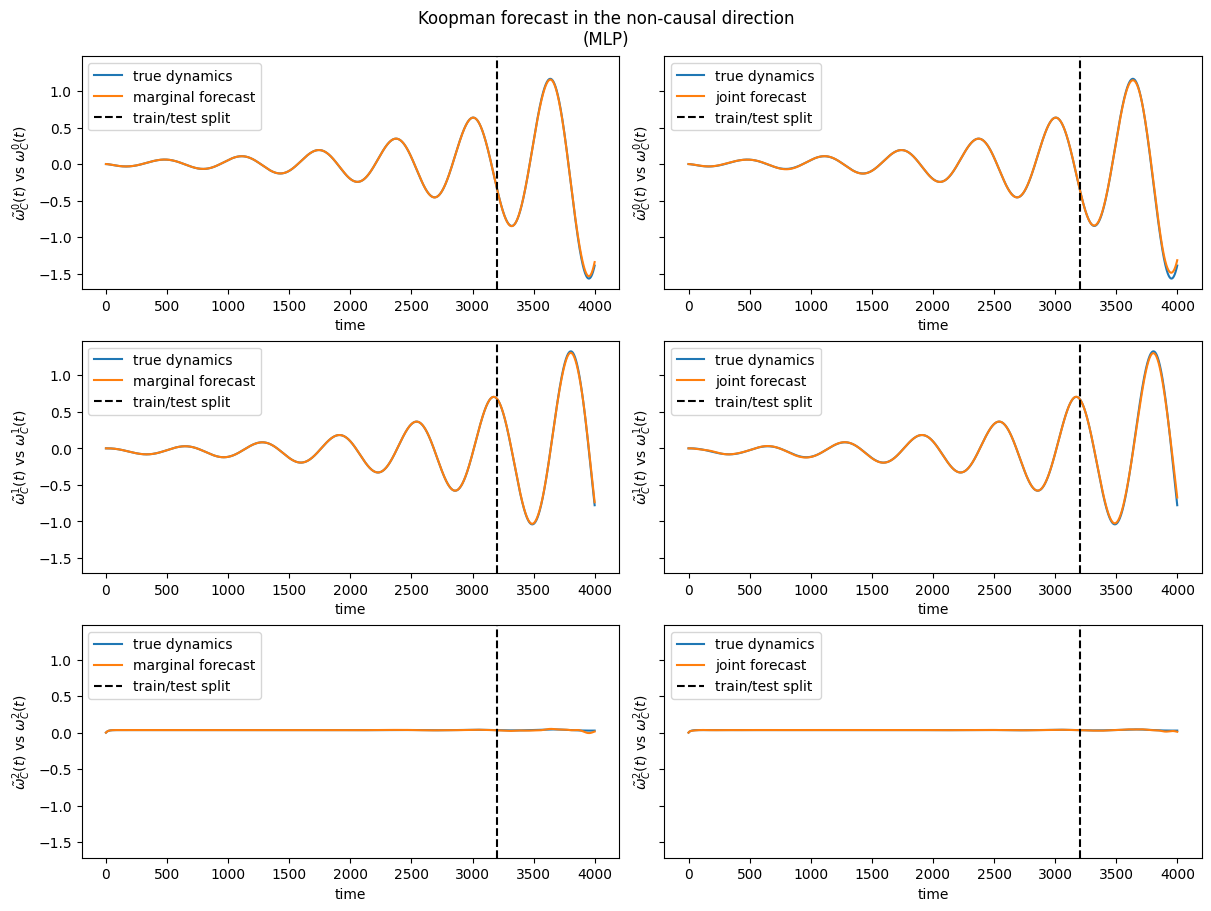

In [20]:
# Plot (conditional inference: non-causal)
fig, ax = plt.subplots(len(effect), 2, figsize=(12, 3 * len(effect)), sharey=True, constrained_layout=True)

for param_id in range(effect.shape[0]):
    # Left subplot: marginal forecast
    ax[param_id, 0].plot(effect[param_id], label='true dynamics')
    ax[param_id, 0].plot(omega_marginal[param_id], label='marginal forecast')
    ax[param_id, 0].axvline(n_train, color='black', linestyle='--', label='train/test split') 
    ax[param_id, 0].set_xlabel('time')
    ax[param_id, 0].set_ylabel(rf'$\tilde{{\omega}}_C^{{{param_id}}}(t)$ vs $\omega_C^{{{param_id}}}(t)$')
    ax[param_id, 0].legend()

    # Right subplot: joint forecast
    ax[param_id, 1].plot(effect[param_id], label='true dynamics')
    ax[param_id, 1].plot(omega_joint[param_id], label='joint forecast')
    ax[param_id, 1].axvline(n_train, color='black', linestyle='--', label='train/test split') 
    ax[param_id, 1].set_xlabel('time')
    ax[param_id, 1].set_ylabel(rf'$\tilde{{\omega}}_C^{{{param_id}}}(t)$ vs $\omega_C^{{{param_id}}}(t)$')
    ax[param_id, 1].legend()

# Add title above all subplots
fig.suptitle('Koopman forecast in the non-causal direction\n(MLP)')
plt.show();
